# Clasical ML model selection

Just like in 06_classification_baseline.ipynb, I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel
from core.utils import extract_subject_id

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_FILE_40_FEATURES, index_col=0)
y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE, index_col=0)

print(f"X Dataset shape: {X_train.shape}")
print(f"X Columns: {list(X_train.columns)}")
display(X_train.head())

print(f"Y Dataset shape: {y_train.shape}")
print(f"Y Columns: {list(y_train.columns)}")
display(y_train.head())

# Class imbalance
print(f"Class distribution: {y_train['is_injured'].value_counts()}")
print(f"Class distribution: {y_train['is_injured'].value_counts(normalize=True)}")

X Dataset shape: (1154, 40)
X Columns: ['age', 'height', 'dom_leg_diff_ankle_df_peak_angle', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_diff_ankle_rot_excursion', 'dom_leg_diff_ankle_rot_peak_angle', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_diff_hip_abd_peak_vel', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ext_peak_angle', 'dom_leg_diff_hip_ext_peak_angle', 'dom_leg_hip_rot_peak_angle', 'dom_leg_diff_hip_rot_peak_angle', 'dom_leg_hip_rot_peak_vel', 'dom_leg_diff_hip_rot_peak_vel', 'dom_leg_diff_knee_add_excursion', 'dom_leg_diff_knee_add_peak_vel', 'dom_leg_knee_flex_peak_angle', 'dom_leg_knee_rot_excursion', 'dom_leg_knee_rot_peak_angle', 'dom_leg_knee_rot_peak_vel', 'dom_leg_diff_knee_rot_peak_vel', 'dom_leg_mhw_exc_from_to', 'dom_leg_diff_mhw_exc_from_to', 'dom_leg_pelvic_drop_peak_

,age,height,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_diff_ankle_rot_excursion,dom_leg_diff_ankle_rot_peak_angle,...,dom_leg_pelvic_drop_peak_vel,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_diff_pelvis_drop_excursion,dom_leg_diff_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.727682,-0.058148,0.633105,1.447539,0.504055,1.352344,0.367857,-0.230089,0.814120,-1.231183,...,0.077306,-0.964662,1.499872,-1.080393,1.983425,-0.244786,-0.024152,0.518204,0.557382,0.334735
100002_20110601T140505,-0.150620,0.088511,-0.769343,-0.891457,-0.128827,0.772460,1.501485,0.540020,0.693086,0.001899,...,0.770352,0.280063,1.441758,-1.778995,-0.857244,0.103879,-0.024152,-0.383164,-0.052167,-1.015686
100004_20110203T120721,-0.326281,0.318975,-0.611548,0.952733,0.213660,-0.265570,-0.682724,-0.340104,0.177909,1.795760,...,0.611224,-0.465172,1.362814,1.364717,-1.532790,-0.020226,-0.024152,-1.184380,0.321218,0.936946
100004_20140929T102035,0.025040,0.256121,-0.597585,-1.235893,-0.149788,-1.023207,-1.082561,0.209973,-0.218022,0.917178,...,1.481642,1.031569,1.266941,0.666114,-0.979693,0.446352,2.242683,-1.284532,0.006865,1.274719
100005_20110208T120837,-0.501941,-1.336177,-0.055702,-0.082042,-0.504754,0.652176,-0.658743,-0.670150,-0.799613,-0.040992,...,0.820841,-0.513202,0.073574,-0.032488,-0.415119,-0.653740,-0.024152,-1.484836,-1.061532,-0.356889


Y Dataset shape: (1154, 1)
Y Columns: ['is_injured']


,is_injured
id,
100001_20110531T161051,True
100002_20110601T140505,True
100004_20110203T120721,True
100004_20140929T102035,False
100005_20110208T120837,True


Class distribution: is_injured
True     838
False    316
Name: count, dtype: int64
Class distribution: is_injured
True     0.72617
False    0.27383
Name: proportion, dtype: float64


In [3]:
neg_pos_ratio = y_train['is_injured'].value_counts().iloc[0] / y_train['is_injured'].value_counts().iloc[1]

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.01, 0.1, 1, 10, 100, 1000],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE,  class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__max_features': ['sqrt', 'log2', None]
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__subsample': [0.8, 0.9, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],  # Add randomess for colinearity
            'classifier__scale_pos_weight': [neg_pos_ratio],  # For class imbalance - See https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
        }
    },
    
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001]
        }
    }
}

In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
subject_ids = extract_subject_id(X_train.index.to_series())

trained_models = {}
results = {}

for model_name, config in models_config.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)
    
    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        cv=cv.split(X_train, y_train, groups=subject_ids),
        #cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    
    grid_search.fit(X_train, y_train)
    
    trained_models[model_name] = grid_search
    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_results': grid_search.cv_results_,
    }
    
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")


Training Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Pe

Best CV Score: 0.5678
Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Training Random Forest...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Docume

Best CV Score: 0.5953
Best Parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

Training XGBoost...
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV Score: 0.5876
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 9, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 2.651898734177215, 'classifier__subsample': 0.8}

Training SVM...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/adrianzapaterreig/Documents/Pe

Best CV Score: 0.6028
Best Parameters: {'classifier__C': 10, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_FILE_40_FEATURES, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_FILE, index_col=0)

X = X_test
y = y_test

for model_name, model in trained_models.items():
    print('\n' + '='*30)
    print(f"Training {model_name}...")
    print('='*30)

    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)

    best_train_score = np.max(model.cv_results_['mean_train_score'])
    test_accuracy = accuracy_score(y, y_pred)
    test_precision = precision_score(y, y_pred, average='weighted')
    test_recall = recall_score(y, y_pred, average='weighted')
    test_f1 = f1_score(y, y_pred, average='weighted')
    test_roc_auc = roc_auc_score(y, y_pred_proba[:, 1])
    
    results[model_name].update({
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    })
    
    print("Validation results:")
    print(f"Best CV Score: {model.best_score_:.4f}")
    print(f"Best Train Score: {best_train_score:.4f}")
    print(f"Best Parameters: {model.best_params_}")
    print("\nTest results:")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    print(f"Test ROC AUC: {test_roc_auc:.4f}")


Training Logistic Regression...
Validation results:
Best CV Score: 0.5678
Best Train Score: 0.6927
Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Test results:
Test Accuracy: 0.5017
Test Precision: 0.5735
Test Recall: 0.5017
Test F1-Score: 0.5267
Test ROC AUC: 0.5005

Training Random Forest...
Validation results:
Best CV Score: 0.5953
Best Train Score: 1.0000
Best Parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

Test results:
Test Accuracy: 0.7143
Test Precision: 0.6279
Test Recall: 0.7143
Test F1-Score: 0.6264
Test ROC AUC: 0.5518

Training XGBoost...
Validation results:
Best CV Score: 0.5876
Best Train Score: 1.0000
Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 9, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight':

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test Accuracy  Test Precision  \
3                  SVM        0.5735         0.7317          0.7366   
1        Random Forest        0.5518         0.7143          0.6279   
2              XGBoost        0.5281         0.7003          0.6071   
0  Logistic Regression        0.5005         0.5017          0.5735   

   Test Recall  Test F1-Score  
3       0.7317         0.6310  
1       0.7143         0.6264  
2       0.7003         0.6230  
0       0.5017         0.5267  

Best performing model: SVM
Best Test ROC AUC Score: 0.5735


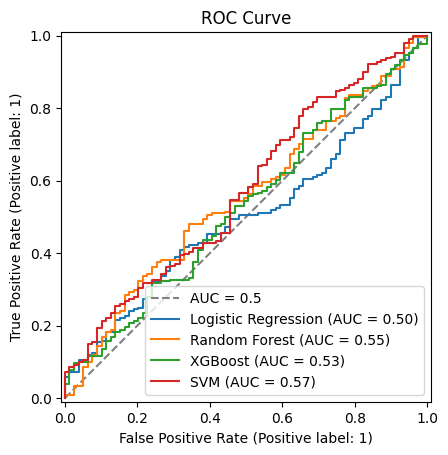

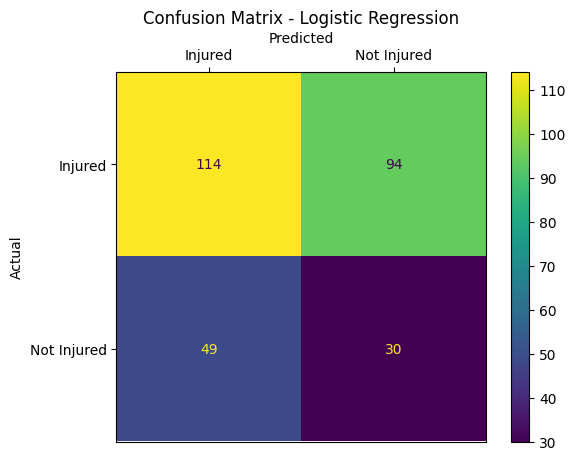

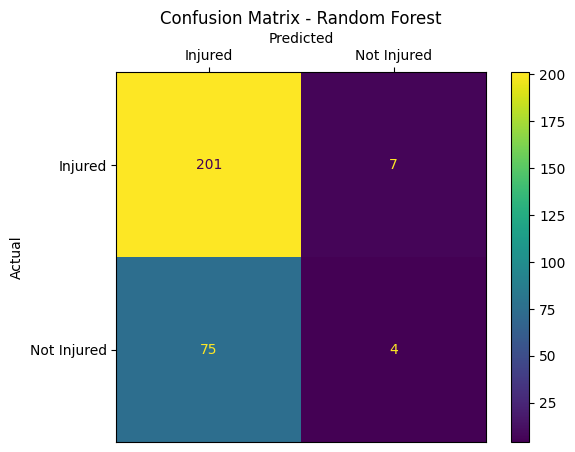

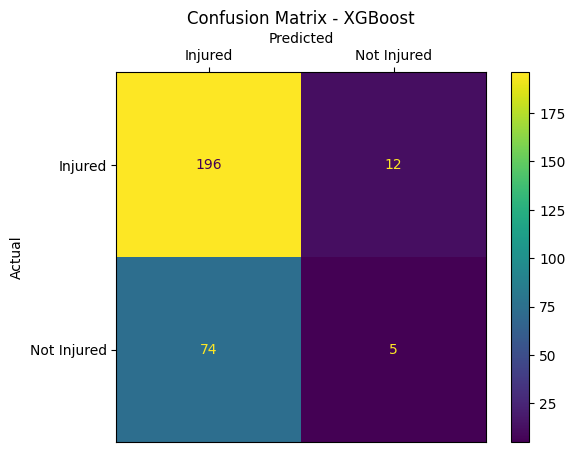

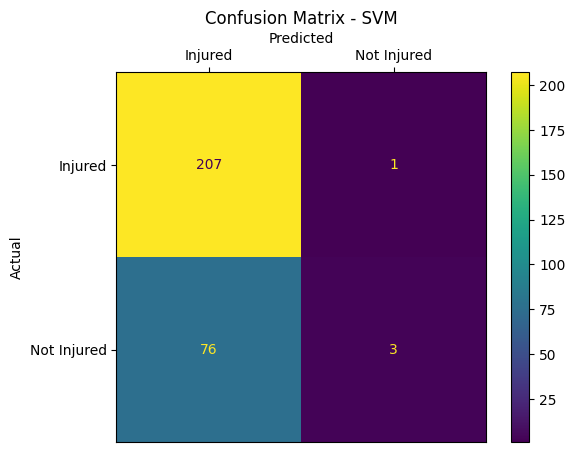

In [6]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['test_roc_auc'],
        'Test Accuracy': result['test_accuracy'],
        'Test Precision': result['test_precision'],
        'Test Recall': result['test_recall'],
        'Test F1-Score': result['test_f1'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'][:, 1], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")